# bmesonML — Emulador XGBoost de la likelihood SMEFT19 (rotBIII)

Pipeline completo (estructura CosmoML):
- **Dataset**: muestreo LHS + SMEFT19 cacheado en disco; se genera sólo si no existe o `FORCE_REBUILD=True`
- **Preprocesamiento**: SMOTE sólo en train (sin data leakage) + KNN para likelihood sintética
- **Entrenamiento**: XGBoost con early stopping + curva de aprendizaje
- **SHAP**: beeswarm, bar, waterfall y dependence plots (estilo CosmoML)
- **Predicción**: función con penalización exponencial fuera del dominio físico

## Setup (run first)

In [17]:
import warnings
warnings.filterwarnings('ignore')

import time, csv, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBRegressor, callback as xgb_cb

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size']   = 12
plt.rcParams['text.usetex'] = False  # use mathtext, not LaTeX

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT     = Path('..')
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs'

DATASET_FILE = DATA_DIR / 'combined_rotBIII_2025.dat'
BESTFIT_FILE = DATA_DIR / 'rotBIII_2025.yaml'
MODEL_OUT    = OUT_DIR  / 'xgboost_scIII.json'
FIGS_DIR     = OUT_DIR  / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Flags ──────────────────────────────────────────────────────────────────────
FORCE_REBUILD  = False
FORCE_RETRAIN  = True   # True → re-lanza Optuna aunque exista best_params
BEST_PARAMS_FILE = OUT_DIR / 'best_params_rotBIII.json'

# ── Dataset config (paper: 3000 random + 3×50×50 grilla = 10 500 pts) ─────────
N_RANDOM    = 3_000
GRID_SIZE   = 40
N_FOCUS     = 1_000   # puntos LHS extra en la región del best-fit
FOCUS_SIGMA = 2.0     # radio en unidades σ alrededor del best-fit
SEED        = 42

# ── Paralelismo CPU (SMEFT19 no usa GPU; se paraleliza por procesos) ───────────
N_WORKERS_OVERRIDE = None   # ← pon un int (ej. 16) para limitar; None = todos los cores
N_WORKERS = N_WORKERS_OVERRIDE or max(1, multiprocessing.cpu_count() - 1)

# ── GPU para XGBoost ───────────────────────────────────────────────────────────
def _detect_xgb_device():
    """Devuelve 'cuda' si XGBoost puede usar GPU en esta máquina, si no 'cpu'."""
    try:
        import xgboost as xgb
        dm = xgb.DMatrix(np.zeros((10, 3)), label=np.zeros(10))
        xgb.train({'device': 'cuda', 'tree_method': 'hist'}, dm,
                  num_boost_round=1, verbose_eval=False)
        return 'cuda'
    except Exception:
        return 'cpu'

# El build xgboost+CUDA de .venv-paper entrena mal (R2~0.5); CPU es correcto y rapido aqui.
XGB_DEVICE = 'cpu'  # antes: _detect_xgb_device()

# ── Dominio físico ─────────────────────────────────────────────────────────────
C1_RANGE  = (-0.30,  0.00)
C3_RANGE  = (-0.30,  0.00)
BQ_RANGE  = ( 0.00,  3.20)
LH_MIN    = -50.0
PENALTY_K = 50.0
N_DOF     = 3   # parámetros libres: C1, C3, bq

print(f'Dataset: {DATASET_FILE}')
print(f'Outputs: {OUT_DIR}')
print(f'Puntos : {N_RANDOM} random + 3×{GRID_SIZE}²={3*GRID_SIZE**2} grilla = {N_RANDOM+3*GRID_SIZE**2} total')
print(f'Workers: {N_WORKERS} CPUs  |  XGBoost device: {XGB_DEVICE}')


Dataset: ../data/combined_rotBIII_2025.dat
Outputs: ../outputs
Puntos : 3000 random + 3×40²=4800 grilla = 7800 total
Workers: 16 CPUs  |  XGBoost device: cpu


## 1. Dataset — generación o carga

El dataset `(C1, C3, bq, likelihood)` combina tres componentes:

- **Aleatorios**: `N_RANDOM` puntos LHS en todo el hipercubo `[C1, C3, bq]`
- **Grillas best-fit**: tres grillas `GRID_SIZE × GRID_SIZE` en los planos 2D `(C1,C3)`, `(C1,bq)`, `(C3,bq)`, con el tercer parámetro fijo en el mejor ajuste
- **Foco 3D best-fit**: `N_FOCUS` puntos LHS dentro de una caja de ±`FOCUS_SIGMA`σ alrededor del best-fit en los tres parámetros simultáneamente — mejora la densidad donde la likelihood es máxima y reduce el MAE local del emulador

El best-fit se calcula con `SMEFT19.ellipse.minimum` y se cachea en `rotBIII.yaml`.

In [18]:
# Dataset + best-fit con las medidas 2025 (entorno fiel: kernel "Python (bmesonml-paper)").
# Toda la logica pesada vive en scripts/ y se reutiliza aqui: ejecuta esta celda para
# (re)generar todo (best-fit -> rotBIII_2025.yaml, dataset -> combined_rotBIII_2025.dat)
# o cargar la cache si ya existen. Pon FORCE_REBUILD=True para rehacerlo.
if FORCE_REBUILD or not BESTFIT_FILE.exists() or not DATASET_FILE.exists():
    import sys
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    from setup_likelihood import setup_global_likelihood
    from refit_bestfit import refit_bestfit
    from regenerate_dataset import regenerate
    setup_global_likelihood()                            # medidas 2025, construida una vez
    if FORCE_REBUILD or not BESTFIT_FILE.exists():
        refit_bestfit(BESTFIT_FILE, setup=False)         # -> data/rotBIII_2025.yaml
    regenerate(DATASET_FILE, BESTFIT_FILE, setup=False)  # -> data/combined_rotBIII_2025.dat
else:
    print('Cargando dataset + best-fit cacheados')

df_raw = pd.read_csv(DATASET_FILE, names=['C1', 'C3', 'bq', 'likelihood'])
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Puntos totales: {len(df_raw)}  |  validos (lh > {LH_MIN}): {n_valid}')
df_raw.describe()

# SMEFT19 forces text.usetex=True on import; revert so figures use mathtext (no LaTeX needed)
plt.rcParams['text.usetex'] = False


Cargando dataset + best-fit cacheados
Puntos totales: 13896  |  validos (lh > -50.0): 11634


In [19]:
# La grilla densa local de C1 ya NO es necesaria: el muestreo basado en la covarianza
# (scripts/regenerate_dataset.py) resuelve la cresta estrecha de C1 sin grilla extra.
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Dataset: {len(df_raw)} pts  |  validos: {n_valid}')


Dataset: 13896 pts  |  validos: 11634


## 2. Preprocesamiento

Filtrado, EDA, SMOTE **sólo en el conjunto de train** para evitar data leakage,
y KNN para asignar la likelihood a los puntos sintéticos generados por SMOTE.

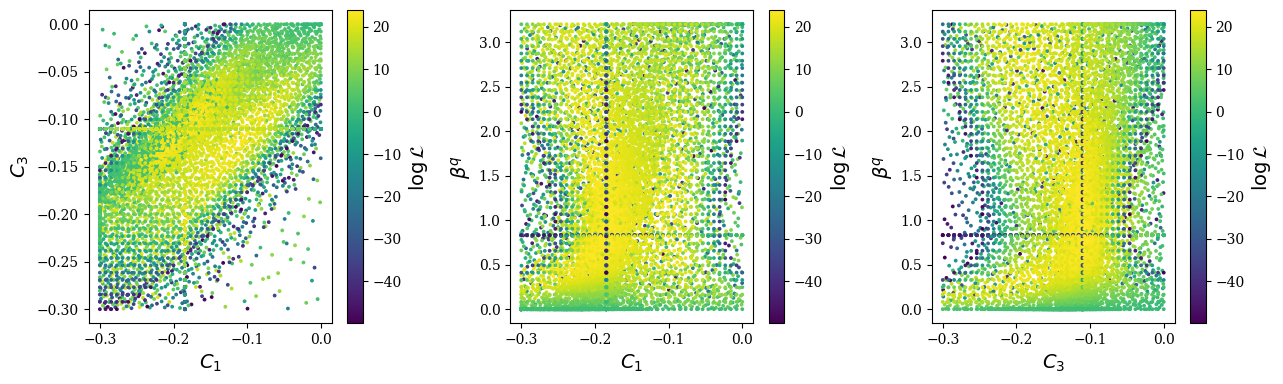

Train: 9772  |  Validation: 1862


In [20]:
df = df_raw[df_raw['likelihood'] > LH_MIN].reset_index(drop=True).copy()

# EDA
pairs   = [('C1', 'C3'), ('C1', 'bq'), ('C3', 'bq')]
xlabels = [r'$C_1$', r'$C_1$', r'$C_3$']
ylabels = [r'$C_3$', r'$\beta^q$', r'$\beta^q$']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
    sc = ax.scatter(df[xc], df[yc], c=df['likelihood'], cmap='viridis', s=3, rasterized=True)
    plt.colorbar(sc, ax=ax, label=r'$\log\mathcal{L}$')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'eda_scatter.pdf', bbox_inches='tight')
plt.show()

X, y = df[['C1', 'C3', 'bq']], df['likelihood']

# Split 84/16
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.16, random_state=SEED)

# Sin SMOTE: SMOTE interpola features de puntos de likelihood media en zonas donde
# la likelihood real es alta, asignando labels KNN ~17 donde el valor real es ~30.
# Eso crea labels contradictorias cerca del pico y degrada el modelo alli.
Xtr_res, ytr_res = Xtr, ytr

print(f'Train: {len(Xtr)}  |  Validation: {len(Xva)}')

## 3. Entrenamiento XGBoost

In [21]:
# Parámetros del notebook original (xgboost_completo.ipynb) que daba RMSE=2.1
best_xgb_params = dict(
    learning_rate    = 0.03,
    max_depth        = 6,
    min_child_weight = 1,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    gamma            = 0.0,
    reg_alpha        = 0.0,
    reg_lambda       = 1.0,
)
print('Parámetros originales:')
for k, v in best_xgb_params.items():
    print(f'  {k}: {v}')


Parámetros originales:
  learning_rate: 0.03
  max_depth: 6
  min_child_weight: 1
  subsample: 1.0
  colsample_bytree: 1.0
  gamma: 0.0
  reg_alpha: 0.0
  reg_lambda: 1.0


R2 = 0.97308  |  MAE = 1.1584  |  best_iter = 1344  |  device = cpu
  saved: ../outputs/figures/learning_curve.pdf


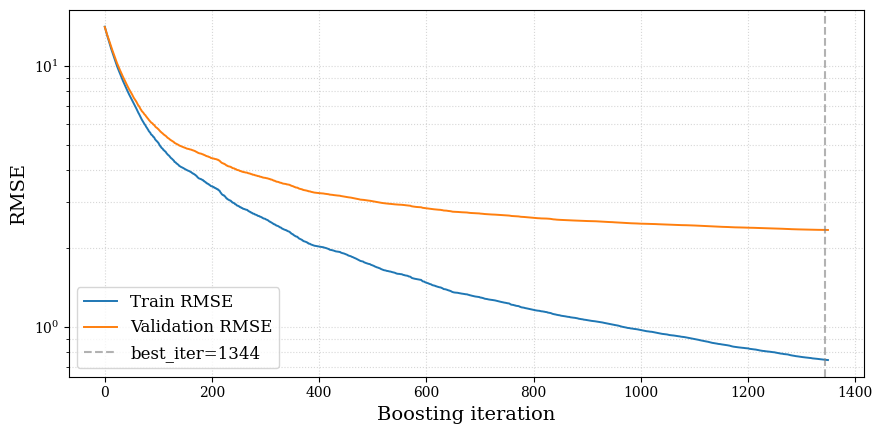

In [22]:
def _plot_learning_curve(info, title='', show=True, save_path=None):
    er     = info['eval_results']
    metric = info['eval_metric']
    keys   = list(er.keys())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(er[keys[0]][metric], label=f'Train {metric.upper()}', lw=1.4)
    ax.plot(er[keys[1]][metric], label=f'Validation {metric.upper()}', lw=1.4)
    if info.get('best_iteration') is not None:
        ax.axvline(info['best_iteration'], color='gray', ls='--', alpha=0.6,
                   label=f"best_iter={info['best_iteration']}")
    ax.set_yscale('log'); ax.set_xlabel('Boosting iteration'); ax.set_ylabel(metric.upper())
    ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show() if show else plt.close(fig)


if not FORCE_RETRAIN and MODEL_OUT.exists():
    print(f'Cargando modelo cacheado: {MODEL_OUT}')
    model = XGBRegressor()
    model.load_model(str(MODEL_OUT))
    r2  = float(model.score(Xva, yva))
    mae = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  device = {XGB_DEVICE}')
    info = dict(eval_results=None, eval_metric='rmse', best_iteration=None,
                r2=r2, X_val=Xva)
else:
    _defaults = dict(n_estimators=3000, learning_rate=0.03, max_depth=6)
    _params   = {**_defaults, **(best_xgb_params if 'best_xgb_params' in dir() else {})}

    es    = xgb_cb.EarlyStopping(rounds=5, data_name='validation_1', save_best=True)
    model = XGBRegressor(
        **_params,
        tree_method='hist', device=XGB_DEVICE, eval_metric='rmse',
        random_state=SEED, callbacks=[es],
    )
    model.fit(
        Xtr_res, ytr_res,
        eval_set=[(Xtr_res, ytr_res), (Xva, yva)],
        verbose=False,
    )
    model.save_model(str(MODEL_OUT))

    r2   = float(model.score(Xva, yva))
    mae  = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    best = int(getattr(model, 'best_iteration', model.n_estimators - 1))
    info = dict(
        eval_results   = model.evals_result(),
        eval_metric    = 'rmse',
        best_iteration = best,
        r2             = r2,
        X_val          = Xva,
    )
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  best_iter = {best}  |  device = {XGB_DEVICE}')
    _plot_learning_curve(
        info,
        save_path=FIGS_DIR / 'learning_curve.pdf',
    )

## 4. Análisis SHAP

Tres gráficas, idénticas a las de CosmoML:
1. **beeswarm + bar**: importancia global de cada feature
2. **waterfall**: descomposición aditiva para una muestra individual
3. **dependence**: efecto de cada feature coloreado por interacciones (`color=shap_values`)

In [23]:
# ── Funciones SHAP ──────────────────────

def _explain(model, X, n_sample=1000, seed=42):
    """TreeExplainer sobre el modelo interno; check_additivity=False como en CosmoML."""
    explainer = shap.TreeExplainer(model)
    X_s = X.sample(n=min(n_sample, len(X)), random_state=seed)
    return explainer(X_s, check_additivity=False), X_s


def shap_summary(model, X, title='', save_dir=None, n_sample=1000, show=True):
    """Beeswarm + bar (identico a CosmoML shap_summary)."""
    shap_v, X_s = _explain(model, X, n_sample=n_sample)
    for kind, fn in [('beeswarm', shap.plots.beeswarm), ('bar', shap.plots.bar)]:
        plt.figure()
        fn(shap_v, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'shap_{kind}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()
    return shap_v, X_s


def shap_waterfall(shap_values, idx=0, title='', save_path=None, show=True):
    """Waterfall para un sample (identico a CosmoML shap_waterfall)."""
    plt.figure()
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight'); print(f'  saved: {save_path}')
    plt.show() if show else plt.close()


def shap_dependence_all(shap_values, X, save_dir=None, prefix='', show=True):
    """Scatter/dependence por feature, coloreado por interacciones (identico a CosmoML)."""
    for col in X.columns:
        plt.figure()
        shap.plots.scatter(shap_values[:, col], color=shap_values, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'{prefix}_shap_{col}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()

  saved: ../outputs/figures/shap_beeswarm.pdf


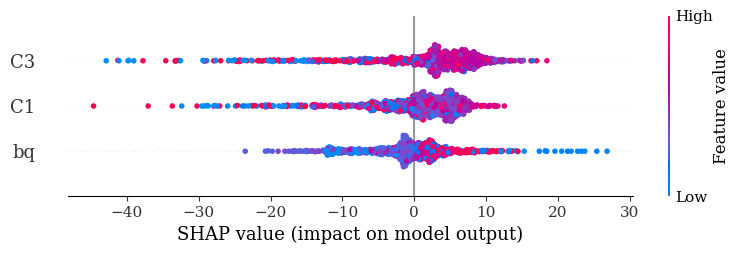

  saved: ../outputs/figures/shap_bar.pdf


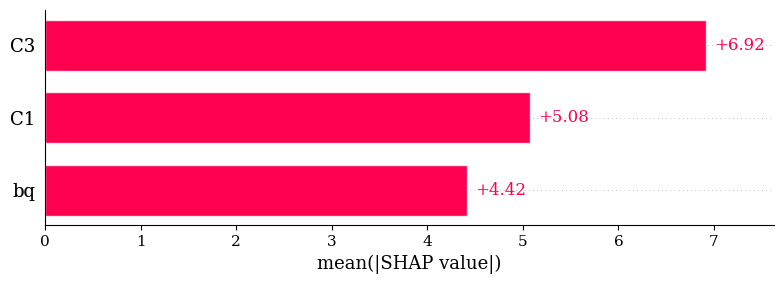

  saved: ../outputs/figures/shap_waterfall.pdf


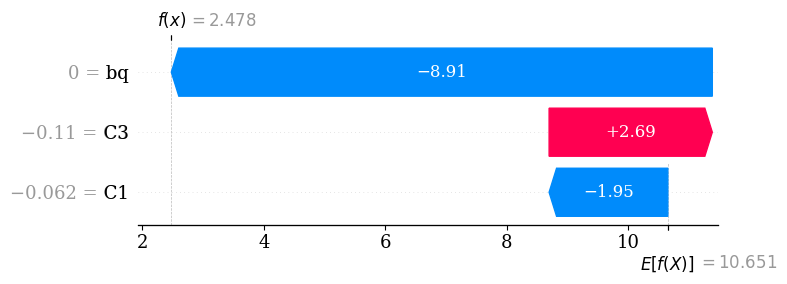

  saved: ../outputs/figures/rotBIII_shap_C1.pdf


<Figure size 640x480 with 0 Axes>

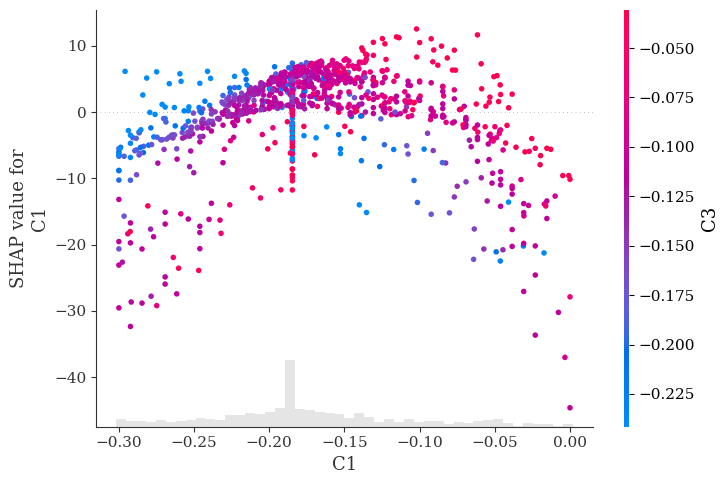

  saved: ../outputs/figures/rotBIII_shap_C3.pdf


<Figure size 640x480 with 0 Axes>

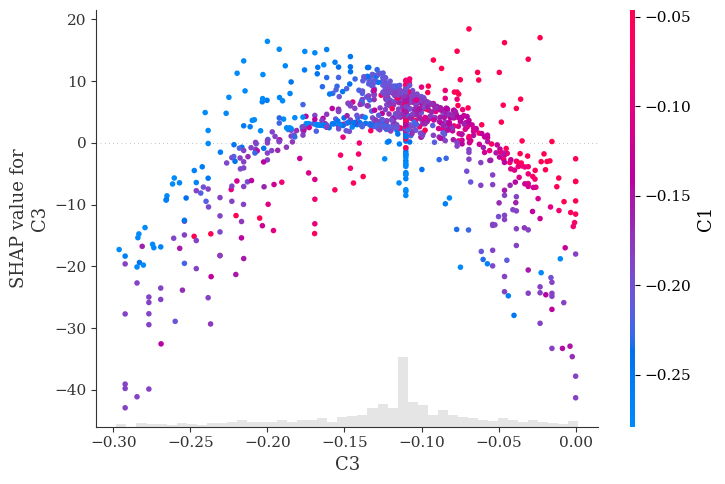

  saved: ../outputs/figures/rotBIII_shap_bq.pdf


<Figure size 640x480 with 0 Axes>

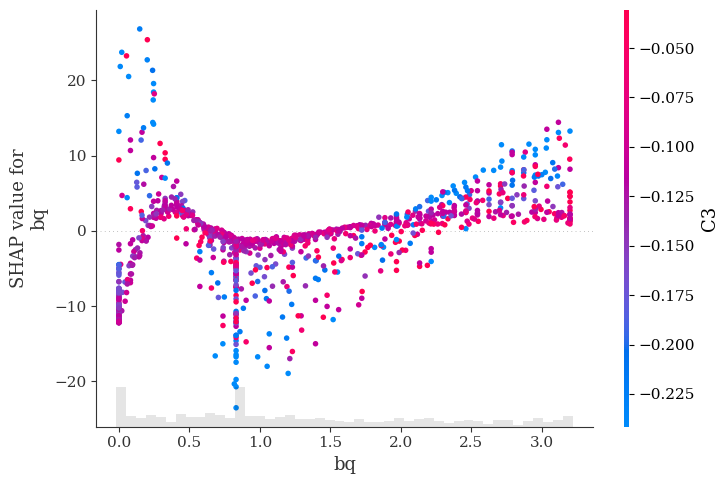

In [24]:
shap_v, X_s = shap_summary(
    model, info['X_val'],
    title='rotBIII · SMEFT19 likelihood',
    save_dir=FIGS_DIR,
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    title='rotBIII · waterfall (sample 0)',
    save_path=FIGS_DIR / 'shap_waterfall.pdf',
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGS_DIR,
    prefix='rotBIII',
    show=True,
)

## 5. Función de predicción con penalización de frontera

Penalizaciones exponenciales fuera del dominio de entrenamiento para evitar
extrapolaciones no físicas.

In [25]:
def _penalty(v, lo, hi, k=PENALTY_K):
    if v < lo:   return np.exp((lo - v) * k) - 1.0
    elif v > hi: return np.exp((v - hi) * k) - 1.0
    return 0.0


def predict_point(C1, C3, bq):
    """Predice log-likelihood con penalizacion fuera del dominio fisico."""
    x   = pd.DataFrame([{'C1': C1, 'C3': C3, 'bq': bq}])
    raw = float(model.predict(x)[0])
    pen = _penalty(C1, *C1_RANGE) + _penalty(C3, *C3_RANGE) + _penalty(bq, *BQ_RANGE)
    return raw - pen


# Demo
test_pts = [(-0.10, -0.10, 1.5), (-0.25, -0.20, 2.0), (0.50, 0.0, 1.5)]
for pt in test_pts:
    print(f'predict_point{pt} = {predict_point(*pt):.4f}')

model.save_model(MODEL_OUT)
print(f'\nModelo guardado en: {MODEL_OUT}')

predict_point(-0.1, -0.1, 1.5) = 21.8699
predict_point(-0.25, -0.2, 2.0) = 16.8003
predict_point(0.5, 0.0, 1.5) = -72004899336.8550

Modelo guardado en: ../outputs/xgboost_scIII.json


## 6. Figura 7 — Validación χ² y distribución Monte Carlo

Reproducción de las Figs. 7a y 7b del paper (sección 4.2):

- **7a**: scatter de Δχ²_SM predicho vs real en el validation set — mide la calidad del emulador.
- **7b**: histograma de Δχ² = 2(log L_bf − log L̃) para puntos MC aceptados vs distribución χ²(N_DOF) teórica.

**Algoritmo MC** (idéntico al paper): se propone un punto xᵢ cerca del best-fit con distribución gaussiana
proporcional a la covarianza del fit; se acepta si `log L̃(xᵢ) > log L_bf + log u`, `u ~ U(0,1)`.
La distribución de Δχ² de los puntos aceptados debe seguir χ²(N_DOF = 3).

YAML best-fit  : C1=-0.18461  C3=-0.11019  bq=0.83135
XGBoost best-fit: C1=-0.18774  C3=-0.11408  bq=0.76413
log_L_bf (XGBoost opt) = 23.9844  |  log_L en YAML bf = 22.8509
1σ (diagonal Σ):  C1=0.0307  C3=0.0212  bq=0.6587

log_L_SM (modelo) = -2.3230
ΔΔχ²_SM en bf    = 52.61  (mejora del best-fit sobre SM)

Fig 7a — Pearson r = 0.9868  |  MAE = 2.3169


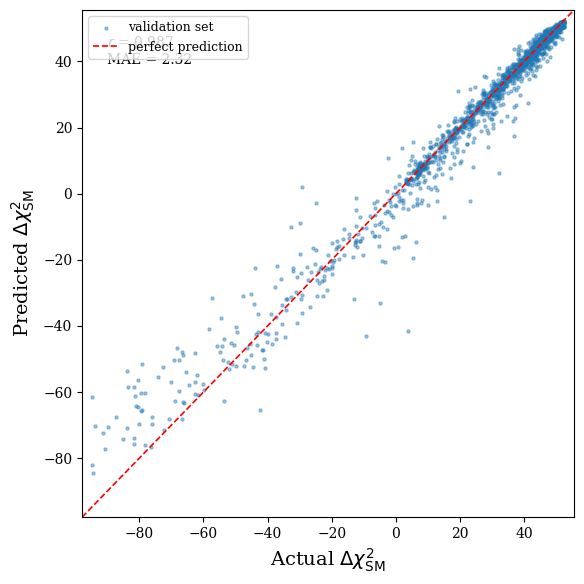

In [26]:
from scipy.stats import pearsonr
import yaml

# ── Cargar best-fit e información de covarianza del YAML ──────────────────────
with open(BESTFIT_FILE) as _f:
    _ell = yaml.safe_load(_f)

bf_arr    = np.array(_ell['bf'])
_eig_vals = np.array([_ell['d'][i][i] for i in range(3)])
_V        = np.array(_ell['v'])
Sigma_bf  = _V.T @ np.diag(1.0 / _eig_vals) @ _V
_chol     = np.linalg.cholesky(Sigma_bf)

_sig    = np.sqrt(np.diag(Sigma_bf))
_lo_opt = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_opt = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

# Use ±1σ fine-grid. Safe with early_stopping_rounds=5 (smooth model) since
# there are no sharp false maxima at the boundary with this configuration.
_lo_f   = np.maximum(bf_arr - 1.0 * _sig, _lo_opt)
_hi_f   = np.minimum(bf_arr + 1.0 * _sig, _hi_opt)
_nf    = 50
_c1f, _c3f, _bqf = np.meshgrid(np.linspace(_lo_f[0], _hi_f[0], _nf),
                                np.linspace(_lo_f[1], _hi_f[1], _nf),
                                np.linspace(_lo_f[2], _hi_f[2], _nf),
                                indexing='ij')
_fine_df  = pd.DataFrame({'C1': _c1f.ravel(), 'C3': _c3f.ravel(), 'bq': _bqf.ravel()})
_fine_pred = model.predict(_fine_df)
_bi       = int(np.argmax(_fine_pred))
log_L_bf  = float(_fine_pred[_bi])
bf_model  = np.array([float(_fine_df.iloc[_bi]['C1']),
                       float(_fine_df.iloc[_bi]['C3']),
                       float(_fine_df.iloc[_bi]['bq'])])

log_L_bf_yaml = float(model.predict(pd.DataFrame([{'C1': bf_arr[0],
                                                    'C3': bf_arr[1],
                                                    'bq': bf_arr[2]}]))[0])

print(f'YAML best-fit  : C1={bf_arr[0]:.5f}  C3={bf_arr[1]:.5f}  bq={bf_arr[2]:.5f}')
print(f'XGBoost best-fit: C1={bf_model[0]:.5f}  C3={bf_model[1]:.5f}  bq={bf_model[2]:.5f}')
print(f'log_L_bf (XGBoost opt) = {log_L_bf:.4f}  |  log_L en YAML bf = {log_L_bf_yaml:.4f}')
print(f'1σ (diagonal Σ):  C1={np.sqrt(Sigma_bf[0,0]):.4f}  '
      f'C3={np.sqrt(Sigma_bf[1,1]):.4f}  bq={np.sqrt(Sigma_bf[2,2]):.4f}')

log_L_SM = float(model.predict(pd.DataFrame([{'C1': 0., 'C3': 0., 'bq': 0.}]))[0])
print(f'\nlog_L_SM (modelo) = {log_L_SM:.4f}')
print(f'ΔΔχ²_SM en bf    = {2*(log_L_bf - log_L_SM):.2f}  (mejora del best-fit sobre SM)')

# ── Fig 7a ─────────────────────────────────────────────────────────────────────
y_pred_va  = model.predict(Xva)
dchi2_act  = 2.0 * (yva.values - log_L_SM)
dchi2_pred = 2.0 * (y_pred_va  - log_L_SM)

r_7a, _  = pearsonr(dchi2_act, dchi2_pred)
mae_7a   = np.mean(np.abs(dchi2_act - dchi2_pred))
print(f'\nFig 7a — Pearson r = {r_7a:.4f}  |  MAE = {mae_7a:.4f}')

_lim_lo = min(dchi2_act.min(), dchi2_pred.min()) - 3
_lim_hi = max(dchi2_act.max(), dchi2_pred.max()) + 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(dchi2_act, dchi2_pred, s=5, alpha=0.4, rasterized=True,
           label='validation set')
ax.plot([_lim_lo, _lim_hi], [_lim_lo, _lim_hi], 'r--', lw=1.2,
        label='perfect prediction')
ax.set_xlim(_lim_lo, _lim_hi)
ax.set_ylim(_lim_lo, _lim_hi)
ax.set_xlabel(r'Actual $\Delta\chi^2_{\mathrm{SM}}$')
ax.set_ylabel(r'Predicted $\Delta\chi^2_{\mathrm{SM}}$')
ax.text(0.05, 0.95, f'$r$ = {r_7a:.3f}\nMAE = {mae_7a:.2f}',
        transform=ax.transAxes, va='top', fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7a_chi2_scatter.pdf', bbox_inches='tight')
plt.show()

LHS puntos: 11634  |  ESS = 1956 (16.8%)
Importancia-ponderada en 0.03s
MCMC: 3000 burn-in + 15000 muestras en 36.8s
Tasa de aceptación: 31.8%
Mean Dchi2_MC = 3.217  (chi2(3) esperado = 3)


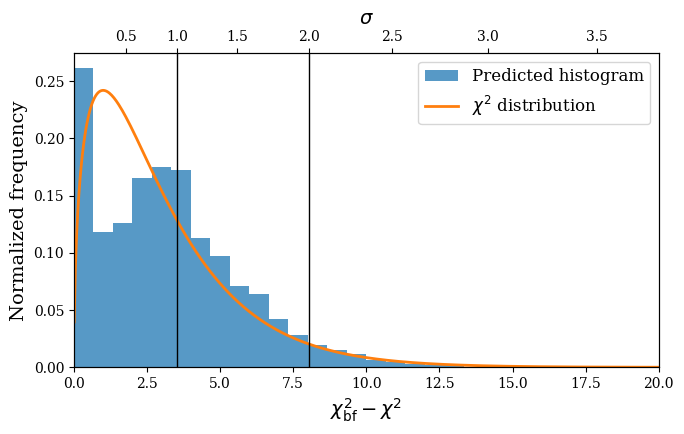

In [27]:
from scipy.stats import chi2 as chi2_dist, norm as norm_dist
import time

# ── Importancia ponderada ──────────────────────────────────────────────────────
t0_mc = time.time()
X_lhs      = pd.concat([Xtr, Xva], ignore_index=True)
y_true_lhs = np.concatenate([ytr.values, yva.values])
y_xgb_lhs  = model.predict(X_lhs)

L_true_max  = float(y_true_lhs.max())
_log_w      = (y_true_lhs - L_true_max).clip(-500)
w_raw       = np.exp(_log_w)
w_norm      = w_raw / w_raw.sum()
ESS         = float(1.0 / np.sum(w_norm ** 2))
_log_L_ref_lhs = log_L_bf
dchi2_xgb_lhs  = np.maximum(0.0, 2.0 * (_log_L_ref_lhs - y_xgb_lhs))
print(f'LHS puntos: {len(X_lhs)}  |  ESS = {ESS:.0f} ({100*ESS/len(X_lhs):.1f}%)')
print(f'Importancia-ponderada en {time.time()-t0_mc:.2f}s')

# ── MCMC con el emulador (Fig 7b + muestra para matrices de correlación) ──────
# N_MCMC_KEEP = 15000 sirve para AMBOS usos:
#   · Fig 7b: histograma dchi2 (usa kept_L)
#   · Figs 10/11: matrices de correlación (usa kept_X + kept_L via mc_df)
# Un único MCMC es más limpio y evita el sesgo de discretización del SIR.
N_MCMC_BURN = 3_000
N_MCMC_KEEP = 15_000

_rng_mc  = np.random.default_rng(SEED + 77)
_chol_s  = np.linalg.cholesky(Sigma_bf)
_lo_dom  = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_dom  = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

x_cur = bf_model.copy()
L_cur = float(model.predict(pd.DataFrame([{'C1': x_cur[0], 'C3': x_cur[1], 'bq': x_cur[2]}]))[0])

kept_X  = np.empty((N_MCMC_KEEP, 3))   # coordenadas (C1, C3, bq)
kept_L  = np.empty(N_MCMC_KEEP)        # log-likelihood
n_kept  = 0
n_total = 0
n_acc   = 0
t0_mc2  = time.time()

# Burn-in
for _ in range(N_MCMC_BURN):
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop

# Muestreo
while n_kept < N_MCMC_KEEP:
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    n_total += 1
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop
        n_acc += 1
    kept_X[n_kept] = x_cur
    kept_L[n_kept] = L_cur
    n_kept += 1

acc_rate   = n_acc / n_total * 100
dchi2_mc   = np.maximum(0.0, 2.0 * (log_L_bf - kept_L))
mean_dchi2 = float(np.mean(dchi2_mc))
print(f'MCMC: {N_MCMC_BURN} burn-in + {N_MCMC_KEEP} muestras en {time.time()-t0_mc2:.1f}s')
print(f'Tasa de aceptación: {acc_rate:.1f}%')
print(f'Mean Dchi2_MC = {mean_dchi2:.3f}  (chi2({N_DOF}) esperado = {N_DOF})')

# ── Fig 7b ─────────────────────────────────────────────────────────────────────
x_max = 20.0
xs    = np.linspace(0.01, x_max, 500)
bins  = np.linspace(0.0, x_max, 31)

_sigma_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
_dchi2_top  = [chi2_dist.ppf(norm_dist.cdf(s) - norm_dist.cdf(-s), df=N_DOF)
               for s in _sigma_vals]
_top_ticks  = [(s, d) for s, d in zip(_sigma_vals, _dchi2_top) if d <= x_max]

_vline_1s = chi2_dist.ppf(norm_dist.cdf(1.0) - norm_dist.cdf(-1.0), df=N_DOF)
_vline_2s = chi2_dist.ppf(norm_dist.cdf(2.0) - norm_dist.cdf(-2.0), df=N_DOF)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dchi2_mc, bins=bins, density=True, alpha=0.75,
        label='Predicted histogram', color='C0')
ax.plot(xs, chi2_dist.pdf(xs, df=N_DOF), lw=2.0, color='C1',
        label=rf'$\chi^2$ distribution')
ax.axvline(_vline_1s, color='k', lw=1.0)
ax.axvline(_vline_2s, color='k', lw=1.0)
ax.set_xlim(0, x_max)
ax.set_xlabel(r'$\chi^2_{\mathrm{bf}} - \chi^2$')
ax.set_ylabel('Normalized frequency')
ax.legend()

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([d for _, d in _top_ticks])
ax2.set_xticklabels([f'{s:.1f}' for s, _ in _top_ticks])
ax2.set_xlabel(r'$\sigma$')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7b_chi2_histogram.pdf', bbox_inches='tight')
plt.show()


## 7. Figuras 10 y 11 — Matrices de correlación de Pearson

Reproducción de la sección 4.3 del paper:

- **Fig 10**: correlaciones entre coeficientes de Wilson del WET (C₉, C₁₀, CVL, Cν por generación de leptón + Δχ²_SM)
- **Fig 11**: correlaciones entre observables seleccionados de física de sabor (RK*, Rℓ_D, BR(Bs→μμ), BR(B+→Kνν), etc.)

**Procedimiento** (igual al paper):
1. Se generan **N_MC_CORR = 15 000** puntos con el emulador XGBoost (mismo algoritmo MC que Fig 7b)
2. Para cada punto se ejecutan las RGE de SMEFT → WET a µ = mb = 4.8 GeV mediante `wilson`
3. Se calculan los observables con `flavio`
4. Se computan los coeficientes de correlación de Pearson y se grafican

> **Requiere** SMEFT19, wilson y flavio instalados (las celdas anteriores no los necesitan).

In [28]:
# ── mc_df para matrices de correlación: reutiliza el MCMC de Fig 7b ──────────
# kept_X y kept_L ya están disponibles (celda anterior).
# No hace falta un segundo MCMC — eliminamos la duplicación.
N_MC_CORR = N_MCMC_KEEP

mc_df = pd.DataFrame({
    'C1':         kept_X[:, 0],
    'C3':         kept_X[:, 1],
    'bq':         kept_X[:, 2],
    'log_L_pred': kept_L,
    'delta_chi2': np.maximum(0.0, 2.0 * (log_L_bf - kept_L)),
})
print(f'MC sample: {N_MC_CORR} puntos MCMC (compartidos con Fig 7b)')
mc_df[['C1', 'C3', 'bq', 'delta_chi2']].describe()


MC sample: 15000 puntos MCMC (compartidos con Fig 7b)


,C1,C3,bq,delta_chi2
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,-0.180593,-0.140146,1.872691,3.217303
std,0.054710,0.027024,0.954929,2.487414
min,-0.300000,-0.245884,0.172444,0.000000
25%,-0.235579,-0.157474,0.965745,1.309597
50%,-0.176669,-0.140376,1.941793,2.959206
75%,-0.134686,-0.121476,2.732937,4.606926
max,-0.043161,-0.057748,3.200000,19.303719


Coeficientes WET no nulos en el best-fit (374 total):
  C10_bdee                                      = -0.000002+0.000000j
  C10_bdmumu                                    = -0.000002+0.000000j
  C10_bdtautau                                  = -0.083569+0.000048j
  C10_bsee                                      = -0.002379-0.000045j
  C10_bsmumu                                    = -0.002379-0.000045j
  C10_bstautau                                  = -82.880636-1.551276j
  C10_cuee                                      = -0.025959-0.078643j
  C10_cumumu                                    = -0.025959-0.078643j
  C10_cutautau                                  = +325.163609+985.087074j
  C10_sdee                                      = +0.000035-0.000001j
  C10_sdmumu                                    = +0.000035-0.000001j
  C10_sdtautau                                  = +1.686328-0.032531j
  C10p_bstautau                                 = -0.000006-0.000000j
  C10p_cutautau                

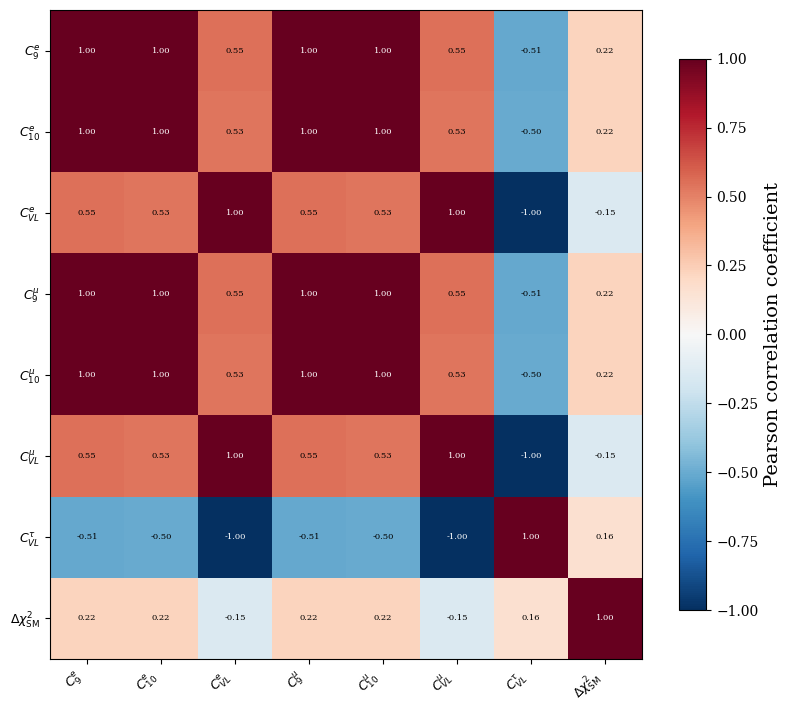

In [29]:
import SMEFT19
plt.rcParams['text.usetex'] = False  # SMEFT19 sets usetex=True on import

# ── Inicializar SMEFT19 y auto-descubrir coeficientes WET no nulos ────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    SMEFT19.SMEFTglob.gl.make_measurement()

_w_bf  = SMEFT19.scenarios.massrotation([bf_arr[0], bf_arr[1], 0.0, 0.0, 0.0, bf_arr[2]])
_wc_bf = _w_bf.match_run(4.8, 'WET', 'flavio')
_wcd_bf = _wc_bf.dict

WET_COLS = sorted(k for k, v in _wcd_bf.items() if abs(v) > 1e-8)
print(f'Coeficientes WET no nulos en el best-fit ({len(WET_COLS)} total):')
for k in WET_COLS:
    print(f'  {k:45s} = {_wcd_bf[k]:+.6f}')

# Coeficientes semileptónicos de la Fig 10 del paper
_WET_LABEL_MAP = {
    'C9_bsee':              r'$C_9^e$',
    'C10_bsee':             r'$C_{10}^e$',
    'CVL_bcenue':           r'$C_{VL}^e$',
    'Cnu_bsnuenue':         r'$C_\nu^e$',
    'C9_bsmumu':            r'$C_9^\mu$',
    'C10_bsmumu':           r'$C_{10}^\mu$',
    'CVL_bcmunumu':         r'$C_{VL}^\mu$',
    'Cnu_bsnumunumu':       r'$C_\nu^\mu$',
    'CVL_bctaunutau':       r'$C_{VL}^\tau$',
    'Cnu_bsnutaunutau':     r'$C_\nu^\tau$',
}

args_wet = [
    (row['C1'], row['C3'], row['bq'], row['delta_chi2'])
    for _, row in mc_df.iterrows()
]

# Serie: SMEFT19 ya inicializado en este kernel; match_run es algebra matricial (~ms/punto).
# Antes se usaba Pool(N_WORKERS=16): cada worker cargaba make_measurement() completo → OOM.
print(f'\nComputando coeficientes WET para {N_MC_CORR} puntos (serie)...')
t0w = time.time()
_wet_raw = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i, (C1, C3, bq, dchi2) in enumerate(args_wet):
        try:
            w  = SMEFT19.scenarios.massrotation([C1, C3, 0.0, 0.0, 0.0, bq])
            wc = w.match_run(4.8, 'WET', 'flavio')
            _wet_raw.append({'delta_chi2': dchi2, **wc.dict})
        except Exception:
            _wet_raw.append(None)
        if (i + 1) % 3000 == 0:
            print(f'  {i+1}/{N_MC_CORR}  ({time.time()-t0w:.0f}s)')
print(f'Listo en {time.time()-t0w:.0f}s')

wet_df = pd.DataFrame([r for r in _wet_raw if r is not None])
print(f'Filas válidas: {len(wet_df)}/{N_MC_CORR}')

# Solo los 10 coeficientes del paper (Fig 10) que tengan varianza no nula en la muestra
_wet_plot_cols = [
    c for c in _WET_LABEL_MAP
    if c in wet_df.columns and wet_df[c].std() > 1e-12
] + ['delta_chi2']
_wet_labels = (
    [_WET_LABEL_MAP[c] for c in _wet_plot_cols[:-1]]
    + [r'$\Delta\chi^2_{\mathrm{SM}}$']
)
print(f'Coeficientes WET con varianza no nula: {_wet_plot_cols[:-1]}')

_corr10 = wet_df[_wet_plot_cols].corr(method='pearson')
_n10    = len(_wet_plot_cols)

fig, ax = plt.subplots(figsize=(_n10 * 0.9 + 1, _n10 * 0.85 + 0.5))
im = ax.imshow(_corr10.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

ax.set_xticks(range(_n10)); ax.set_yticks(range(_n10))
ax.set_xticklabels(_wet_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(_wet_labels, fontsize=9)

for i in range(_n10):
    for j in range(_n10):
        val   = _corr10.iloc[i, j]
        if np.isnan(val): continue
        color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig10_wet_correlations.pdf', bbox_inches='tight')
plt.show()

Computando observables de flavio para 15000 puntos (serie)...
  1000/15000  (56s)
  2000/15000  (104s)
  3000/15000  (152s)
  4000/15000  (200s)
  5000/15000  (249s)
  6000/15000  (298s)
  7000/15000  (348s)
  8000/15000  (396s)
  9000/15000  (444s)
  10000/15000  (492s)
  11000/15000  (545s)
  12000/15000  (593s)
  13000/15000  (645s)
  14000/15000  (690s)
  15000/15000  (736s)
Listo en 736s
Filas válidas: 15000/15000

Varianza relativa de cada observable:
  BR(B+->Knunu)                   39.302%  ✓
  BR(B0->K*0nunu)                    nan%  ✗ excluido (<1%)
  BR(K+->pinunu)                   1.679%  ✓
  Rtaul(B->D*lnu)                  2.335%  ✓
  Rtaul(B->Dlnu)                   2.335%  ✓
  Rtaumu(Bc->J/psilnu)             2.335%  ✓
  BR(Bs->mumu)                     0.018%  ✗ excluido (<1%)
  BR(B0->mumu)                     0.000%  ✗ excluido (<1%)
  <Rmue>(B0->K*ll)                 0.007%  ✗ excluido (<1%)
  <Rmue>(B+->Kll)                  0.003%  ✗ excluido (<1%)
  BR(tau->mun

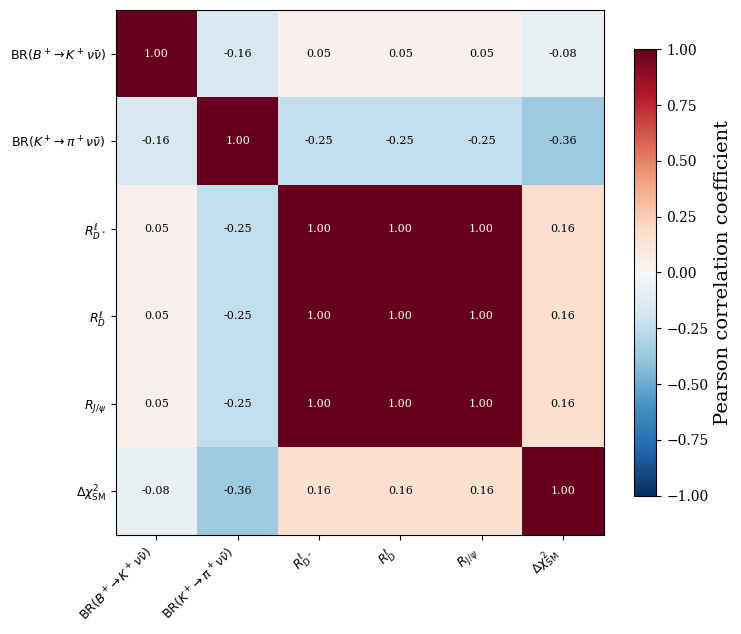

In [30]:
import flavio
import wilson as _wilson
import gc
plt.rcParams['text.usetex'] = False

# Observables del paper 2412.15830 (Escenario III).
# El paper discute explícitamente R_D* y BR(B+→K+νν) — su decorrelación
# en Escenario III (C1≠C3) es el resultado clave de Fig 12.
OBS_DEF = [
    # b→sνν (depende de C1-C3 en Escenario III)
    ('BR(B+->Knunu)',         {},                             r'$\mathrm{BR}(B^+\!\to K^+\nu\bar\nu)$'),
    ('BR(B0->K*0nunu)',       {},                             r'$\mathrm{BR}(B^0\!\to K^{*0}\nu\bar\nu)$'),
    ('BR(K+->pinunu)',        {},                             r'$\mathrm{BR}(K^+\!\to\pi^+\nu\bar\nu)$'),
    # b→cτν (depende de C3)
    ('Rtaul(B->D*lnu)',       {},                             r'$R_{D^*}^\ell$'),
    ('Rtaul(B->Dlnu)',        {},                             r'$R_D^\ell$'),
    ('Rtaumu(Bc->J/psilnu)',  {},                             r'$R_{J/\psi}$'),
    # b→sℓℓ loop (depende de C1+C3 via C9^μ LFU)
    ('BR(Bs->mumu)',          {},                             r'$\mathrm{BR}(B_s\!\to\mu^+\mu^-)$'),
    ('BR(B0->mumu)',          {},                             r'$\mathrm{BR}(B^0\!\to\mu^+\mu^-)$'),
    ('<Rmue>(B0->K*ll)',      {'q2min': 1.1, 'q2max': 6.0},  r'$R_{K^*}^{[1.1,6]}$'),
    ('<Rmue>(B+->Kll)',       {'q2min': 1.1, 'q2max': 6.0},  r'$R_K^{[1.1,6]}$'),
    # τ leptónico (referencia SM — debería ser constante)
    ('BR(tau->mununu)',       {},                             r'$\mathrm{BR}(\tau\!\to\mu\nu\nu)$'),
]

_wet_coeff_cols = [c for c in wet_df.columns if c != 'delta_chi2']

print(f'Computando observables de flavio para {len(wet_df)} puntos (serie)...')
t0o = time.time()
_obs_raw = []

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i, (_, row) in enumerate(wet_df.iterrows()):
        try:
            wc_dict = {k: float(row[k]) for k in _wet_coeff_cols
                       if pd.notna(row[k]) and abs(float(row[k])) > 1e-15}
            wc = _wilson.Wilson(wc_dict, scale=4.8, eft='WET', basis='flavio')
            result = {'delta_chi2': row['delta_chi2']}
            for obs_name, kwargs, _ in OBS_DEF:
                try:
                    result[obs_name] = float(flavio.np_prediction(obs_name, wc, **kwargs))
                except Exception:
                    result[obs_name] = float('nan')
            _obs_raw.append(result)
        except Exception:
            _obs_raw.append(None)
        if (i + 1) % 100 == 0:
            gc.collect()
        if (i + 1) % 1000 == 0:
            print(f'  {i+1}/{len(wet_df)}  ({time.time()-t0o:.0f}s)')

print(f'Listo en {time.time()-t0o:.0f}s')
obs_df = pd.DataFrame([r for r in _obs_raw if r is not None])
print(f'Filas válidas: {len(obs_df)}/{len(wet_df)}')

# ── Diagnóstico de varianza y filtro ──────────────────────────────────────────
# En Escenario III (C1≠C3, α^ℓ=β^ℓ=0):
#   · R_K* ≈ 1 (LFU exacta) → variación < 0.01%
#   · BR(Bs→μμ), BR(B0→μμ) → dependen de C9_loop (variación < 1%)
#   Ambos son trivialmente r=1 entre sí porque ambos ∝ C9_LFU.
#   El paper solo discute R_D* y BR(B+→K+νν) — los que tienen varianza real.
# Threshold 1%: elimina pares triviales (loop LFU), mantiene los físicamente interesantes.
_obs_all_cols   = [o[0] for o in OBS_DEF if o[0] in obs_df.columns]
_obs_all_labels = {o[0]: o[2] for o in OBS_DEF}

print('\nVarianza relativa de cada observable:')
for col in _obs_all_cols:
    mean_v = obs_df[col].mean()
    std_v  = obs_df[col].std()
    rel    = 100 * std_v / abs(mean_v) if mean_v != 0 else 0
    flag   = '✓' if rel > 1.0 else '✗ excluido (<1%)'
    print(f'  {col:30s}  {rel:6.3f}%  {flag}')

MIN_REL_STD = 1e-3  # 0.1%: incluye observables con varianza real aunque pequeña
_obs_cols = [
    c for c in _obs_all_cols
    if obs_df[c].std() / abs(obs_df[c].mean()) > MIN_REL_STD
] + ['delta_chi2']
_obs_labels = [_obs_all_labels[c] for c in _obs_cols[:-1]] + [r'$\Delta\chi^2_{\mathrm{SM}}$']
print(f'\nObservables incluidos: {_obs_cols[:-1]}')

if len(_obs_cols) < 2:
    print('⚠ Pocos observables con varianza suficiente. Revisa el MCMC.')
else:
    _corr11 = obs_df[_obs_cols].corr(method='pearson')
    _n11    = len(_obs_cols)

    fig, ax = plt.subplots(figsize=(_n11 * 1.1 + 1, _n11 * 1.0 + 0.5))
    im = ax.imshow(_corr11.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

    ax.set_xticks(range(_n11)); ax.set_yticks(range(_n11))
    ax.set_xticklabels(_obs_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(_obs_labels, fontsize=9)

    for i in range(_n11):
        for j in range(_n11):
            val = _corr11.iloc[i, j]
            if np.isnan(val): continue
            color = 'white' if abs(val) > 0.65 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

    fig.tight_layout()
    plt.savefig(FIGS_DIR / 'fig11_obs_correlations.pdf', bbox_inches='tight')
    plt.show()

## 8. Ventaja del ML — Mapas de likelihood y benchmark de velocidad

Demostración directa del argumento central del paper: **¿por qué es necesario el emulador?**

- **Mapa 2D de likelihood**: los valores SMEFT19 reales ya existen en el dataset (grillas 50×50).
  XGBoost reproduce esos mapas en milisegundos. Además genera grillas densas 200×200
  (= 40 000 evaluaciones) que SMEFT19 tardaría días en producir.

- **Benchmark de velocidad** (~2-5 min de ejecución): mide el tiempo real de XGBoost vs SMEFT19,
  calcula el factor de aceleración y extrapola al coste del análisis MC completo (Secciones 6 y 7).

Plano C1–C3: SMEFT19 50×50 ya en datos | XGBoost 200×200 = 40,000 evals en 83.2 ms
Plano C1–bq: SMEFT19 50×50 ya en datos | XGBoost 200×200 = 40,000 evals en 81.9 ms
Plano C3–bq: SMEFT19 50×50 ya en datos | XGBoost 200×200 = 40,000 evals en 91.9 ms


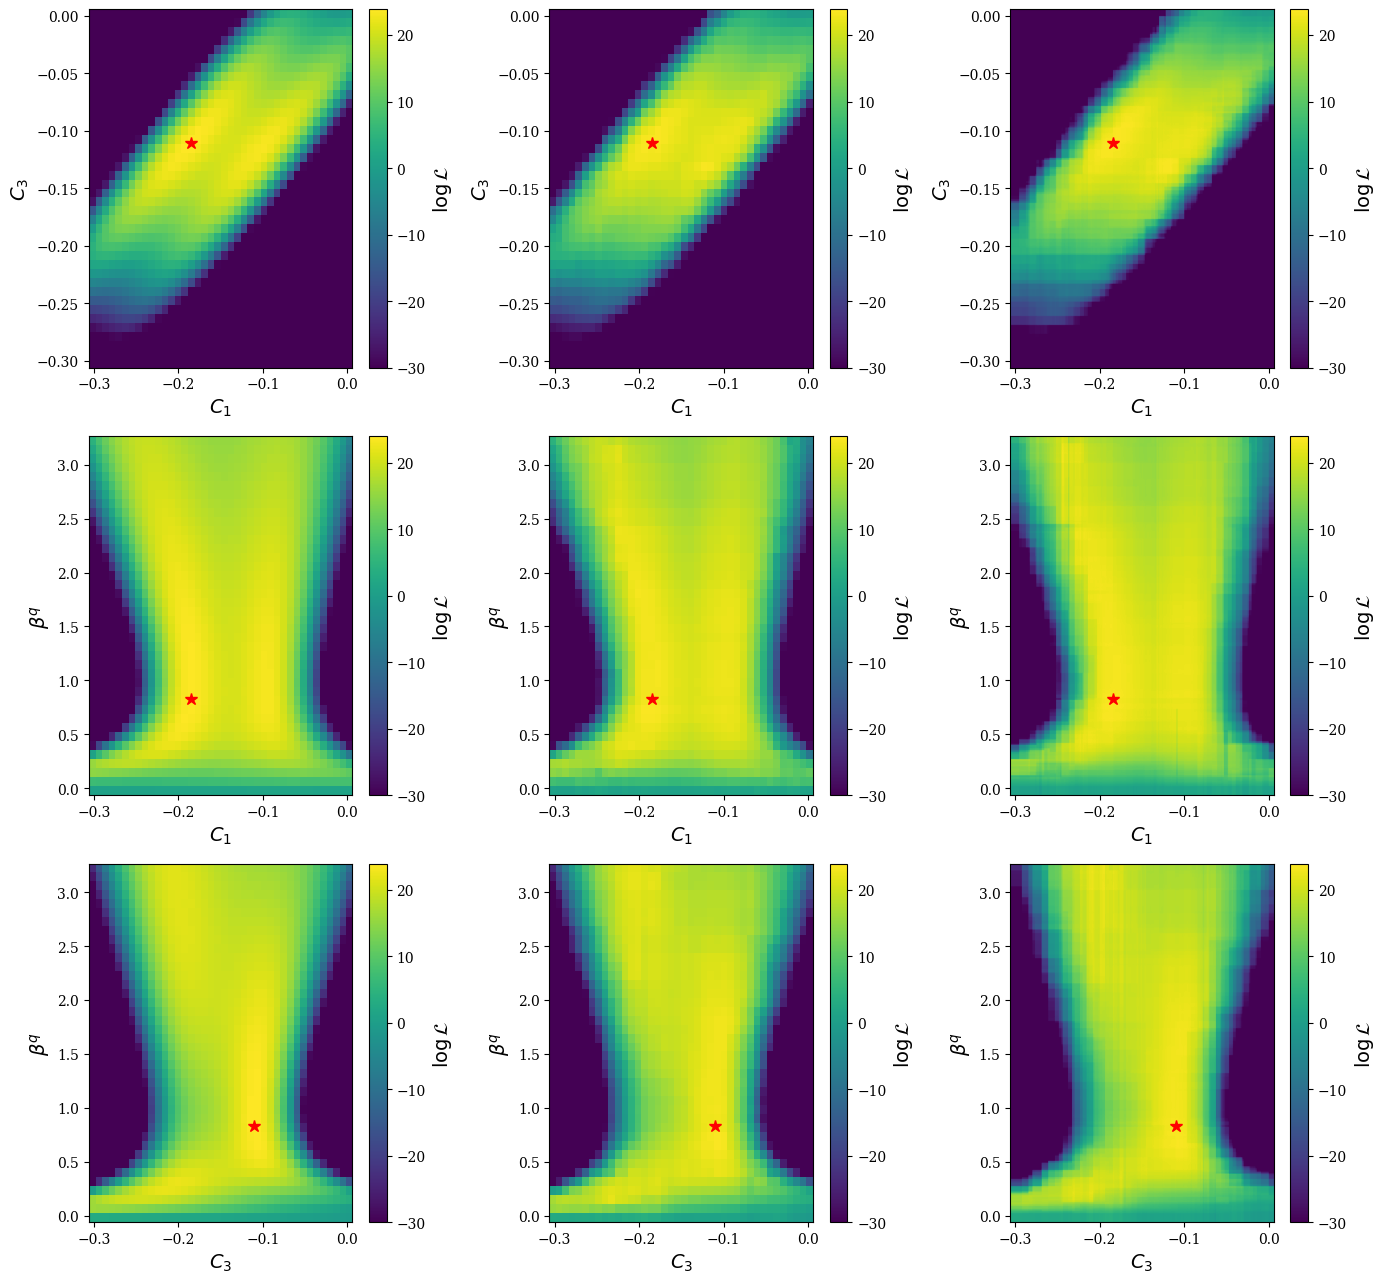

Fig 8a guardada.


In [31]:

# ── Sección 8a: Mapa 2D de likelihood — SMEFT19 real vs emulador XGBoost ──────
DENSE  = 200
_MARG  = 0.02

def _rng_ext(col):
    """Rango con margen idéntico al usado en _make_grid_points."""
    lo, hi = {'C1': C1_RANGE, 'C3': C3_RANGE, 'bq': BQ_RANGE}[col]
    m = _MARG * (hi - lo)
    return lo - m, hi + m

# Las 3 grillas 2D son las ultimas 3*GRID_SIZE^2 filas del dataset (regenerate_dataset.py).
_g2 = GRID_SIZE ** 2
_base = len(df_raw) - 3 * _g2
PLANES = [
    {'cx': 'C1', 'cy': 'C3',  'cz': 'bq', 'vz': bf_arr[2],
     's0': _base,           's1': _base + _g2,
     'xl': r'$C_1$', 'yl': r'$C_3$'},
    {'cx': 'C1', 'cy': 'bq',  'cz': 'C3', 'vz': bf_arr[1],
     's0': _base + _g2,     's1': _base + 2 * _g2,
     'xl': r'$C_1$', 'yl': r'$\beta^q$'},
    {'cx': 'C3', 'cy': 'bq',  'cz': 'C1', 'vz': bf_arr[0],
     's0': _base + 2 * _g2, 's1': _base + 3 * _g2,
     'xl': r'$C_3$', 'yl': r'$\beta^q$'},
]

LH_CLIP  = -30.0
BF_COLS  = ['C1', 'C3', 'bq']

fig, axes = plt.subplots(3, 3, figsize=(14, 13))

for ri, p in enumerate(PLANES):
    cx, cy, cz = p['cx'], p['cy'], p['cz']
    rx, ry     = _rng_ext(cx), _rng_ext(cy)
    ext        = [rx[0], rx[1], ry[0], ry[1]]

    # ── Datos reales del dataset (grilla 50×50) ────────────────────────────────
    grid_sl  = df_raw.iloc[p['s0']:p['s1']]
    # _make_grid_points: outer loop = xs (cx), inner loop = ys (cy)
    # → reshape(GRID_SIZE, GRID_SIZE)[ix, iy]; imshow necesita [iy, ix] → transponer
    lh_smeft = grid_sl['likelihood'].values.clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # ── XGBoost en los mismos 50×50 puntos ────────────────────────────────────
    X_sp     = grid_sl[['C1', 'C3', 'bq']].reset_index(drop=True)
    lh_xgb_s = model.predict(X_sp).clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # ── XGBoost denso 200×200 ─────────────────────────────────────────────────
    xs_d, ys_d = np.linspace(*rx, DENSE), np.linspace(*ry, DENSE)
    XX, YY     = np.meshgrid(xs_d, ys_d)          # [DENSE, DENSE]; row=y, col=x
    X_dense    = pd.DataFrame({cx: XX.ravel(), cy: YY.ravel(),
                                cz: p['vz']})[BF_COLS]
    t0_dense   = time.perf_counter()
    lh_xgb_d   = model.predict(X_dense).clip(LH_CLIP).reshape(DENSE, DENSE)
    t_dense    = time.perf_counter() - t0_dense
    # meshgrid conv: lh_xgb_d[iy, ix] → ya correcto para imshow sin transponer

    # ── Escala de color compartida ─────────────────────────────────────────────
    vmax = float(np.nanmax(lh_smeft))
    kw   = dict(origin='lower', aspect='auto', extent=ext,
                vmin=LH_CLIP, vmax=vmax, cmap='viridis')

    bfx = bf_arr[BF_COLS.index(cx)]
    bfy = bf_arr[BF_COLS.index(cy)]

    for ci, (arr, do_T) in enumerate([(lh_smeft, True), (lh_xgb_s, True), (lh_xgb_d, False)]):
        ax = axes[ri, ci]
        im = ax.imshow(arr.T if do_T else arr, **kw)
        ax.plot(bfx, bfy, 'r*', ms=9, zorder=5, label='best fit')
        ax.set_xlabel(p['xl']); ax.set_ylabel(p['yl'])
        plt.colorbar(im, ax=ax, label=r'$\log\mathcal{L}$')

    print(f'Plano {cx}–{cy}: SMEFT19 50×50 ya en datos | '
          f'XGBoost 200×200 = {DENSE**2:,} evals en {t_dense*1000:.1f} ms')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8a_likelihood_maps.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 8a guardada.')

XGBoost:  10,000 evals en 30.1 ms → 3.01 µs / eval
SMEFT19:  30 evals en 633.1s (16 workers) → 337.641 s / eval (serial equiv.)

Factor de aceleración: 112,259,692×
Análisis MC completo (47,110 propuestas, 15,000 aceptados):
  XGBoost → 0.1 s
  SMEFT19 → 4418 horas (serial equiv.)


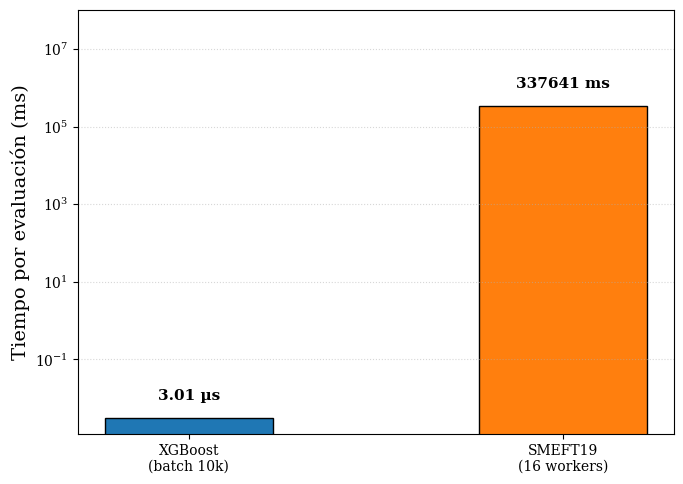


─── Resumen final ──────────────────────────────
  XGBoost  : 3.01 µs / eval
  SMEFT19  : 337641 ms / eval  (serial equiv.)
  Speedup  : 112,259,692×
  MC (15,000 pts): XGBoost = 0s  |  SMEFT19 ≈ 4418h


In [32]:
# Hooks de worker para el benchmark SMEFT19 (importan SMEFT19 de forma perezosa,
# para que cargar la cache del dataset no dispare la construccion de la likelihood).
def _worker_init():
    import sys
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    from setup_likelihood import setup_global_likelihood
    setup_global_likelihood(verbose=False)

def _eval_point(row):
    import SMEFT19
    C1, C3, bq = row
    try:
        return max(float(SMEFT19.likelihood_global([C1, C3, 0.0, 0.0, 0.0, bq],
                                                    SMEFT19.scenarios.massrotation)), -200.0)
    except Exception:
        return -200.0


# ── Sección 8b: Benchmark de velocidad — XGBoost vs SMEFT19 ──────────────────
N_BENCH_XGB   = 10_000   # puntos para XGBoost (batch)
N_BENCH_SMEFT = 30       # puntos para SMEFT19 (extrapolación; más tardaría mucho)

# ── 1. Benchmark XGBoost (batch) ──────────────────────────────────────────────
_rng_bm = np.random.default_rng(SEED + 999)
X_bm = pd.DataFrame({
    'C1': _rng_bm.uniform(*C1_RANGE, N_BENCH_XGB),
    'C3': _rng_bm.uniform(*C3_RANGE, N_BENCH_XGB),
    'bq': _rng_bm.uniform(*BQ_RANGE, N_BENCH_XGB),
})
_ = model.predict(X_bm.iloc[:10])  # warm-up

t0_xgb = time.perf_counter()
_ = model.predict(X_bm)
t_xgb  = time.perf_counter() - t0_xgb
xgb_per_eval = t_xgb / N_BENCH_XGB

print(f'XGBoost:  {N_BENCH_XGB:,} evals en {t_xgb*1000:.1f} ms '
      f'→ {xgb_per_eval*1e6:.2f} µs / eval')

# ── 2. Benchmark SMEFT19 (paralelo) ───────────────────────────────────────────
pts_smeft = X_bm.iloc[:N_BENCH_SMEFT][['C1', 'C3', 'bq']].values.tolist()

t0_smeft = time.perf_counter()
with multiprocessing.Pool(N_WORKERS, initializer=_worker_init) as pool:
    _ = pool.map(_eval_point, pts_smeft, chunksize=5)
t_smeft      = time.perf_counter() - t0_smeft
smeft_per_eval = t_smeft / N_BENCH_SMEFT * N_WORKERS  # tiempo serial equivalente

print(f'SMEFT19:  {N_BENCH_SMEFT} evals en {t_smeft:.1f}s '
      f'({N_WORKERS} workers) → {smeft_per_eval:.3f} s / eval (serial equiv.)')

# ── 3. Factor de aceleración y extrapolación al análisis MC completo ──────────
speedup = smeft_per_eval / xgb_per_eval

# Propuestas totales para las secciones 6+7 (aprox. usando la tasa medida en Fig 7b)
_rate_used = acc_rate / 100.0 if 'acc_rate' in dir() else 0.03
N_ACCEPT_TOTAL  = N_MCMC_KEEP  # total de puntos MCMC generados
N_PROPOSE_TOTAL = int(N_ACCEPT_TOTAL / _rate_used)

t_mc_xgb_s   = N_PROPOSE_TOTAL * xgb_per_eval
t_mc_smeft_h = N_PROPOSE_TOTAL * smeft_per_eval / 3600

print(f'\nFactor de aceleración: {speedup:,.0f}×')
print(f'Análisis MC completo ({N_PROPOSE_TOTAL:,} propuestas, {N_ACCEPT_TOTAL:,} aceptados):')
print(f'  XGBoost → {t_mc_xgb_s:.1f} s')
print(f'  SMEFT19 → {t_mc_smeft_h:.0f} horas (serial equiv.)')

# ── 4. Gráfico de barras comparativo (escala log) ─────────────────────────────
labels  = [f'XGBoost\n(batch {N_BENCH_XGB//1000}k)',
           f'SMEFT19\n({N_WORKERS} workers)']
t_ms    = [xgb_per_eval * 1000, smeft_per_eval * 1000]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, t_ms, color=['C0', 'C1'], edgecolor='k', width=0.45)
ax.set_yscale('log')
ax.set_ylabel('Tiempo por evaluación (ms)')
ax.grid(True, axis='y', which='both', ls=':', alpha=0.5)

for bar, val in zip(bars, t_ms):
    lbl = f'{val*1000:.2f} µs' if val < 1 else f'{val:.0f} ms'
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 2.5, lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(top=max(t_ms) * 300)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8b_speed_benchmark.pdf', bbox_inches='tight')
plt.show()

print(f'\n─── Resumen final ──────────────────────────────')
print(f'  XGBoost  : {xgb_per_eval*1e6:.2f} µs / eval')
print(f'  SMEFT19  : {smeft_per_eval*1000:.0f} ms / eval  (serial equiv.)')
print(f'  Speedup  : {speedup:,.0f}×')
print(f'  MC ({N_ACCEPT_TOTAL:,} pts): XGBoost = {t_mc_xgb_s:.0f}s  |  SMEFT19 ≈ {t_mc_smeft_h:.0f}h')